# Immune Checkpoint Expression Atlas

This notebook builds a compact expression atlas for selected immune checkpoint and checkpoint-associated genes using Human Protein Atlas immune-cell RNA expression data.

## Analysis question

Which immune checkpoint genes are expressed across immune cell types, and which cell types show the strongest expression profiles?

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from process_checkpoint_expression import (
    TARGET_CHECKPOINT_GENES,
    clean_checkpoint_expression,
    load_raw_expression,
    make_ranked_expression,
    make_wide_expression,
)

sns.set_theme(style="whitegrid", context="notebook")

## Data and selected genes

The raw table is `data/raw/rna_immune_cell.tsv`. The analysis keeps the checkpoint gene set used by the project scripts: PDCD1, CD274, CTLA4, TIGIT, LAG3, HAVCR2, TOX, ENTPD1, ICOS, and TNFRSF9.

The cleaning step standardizes gene symbols and immune-cell labels, filters to the selected genes, averages duplicate gene/cell-type measurements, and exports long, wide, and ranked tables for downstream plots and the dashboard.

In [3]:
raw_expression = load_raw_expression(PROJECT_ROOT / "data" / "raw" / "rna_immune_cell.tsv")
long_expression = clean_checkpoint_expression(raw_expression)
wide_expression = make_wide_expression(long_expression)
ranked_expression = make_ranked_expression(long_expression)

processed_dir = PROJECT_ROOT / "data" / "processed"
reports_dir = PROJECT_ROOT / "reports"
processed_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

long_expression.to_csv(processed_dir / "checkpoint_expression_long.csv", index=False)
wide_expression.to_csv(processed_dir / "checkpoint_expression_wide.csv", index=False)
ranked_expression.to_csv(reports_dir / "top_cell_types_per_gene.csv", index=False)

summary = pd.DataFrame(
    {
        "metric": ["raw rows", "checkpoint genes", "immune cell types", "processed rows", "max TPM"],
        "value": [
            len(raw_expression),
            long_expression["gene"].nunique(),
            long_expression["cell_type"].nunique(),
            len(long_expression),
            long_expression["expression"].max(),
        ],
    }
)
summary

,metric,value
0,raw rows,383078.0
1,checkpoint genes,10.0
2,immune cell types,19.0
3,processed rows,190.0
4,max TPM,166.9


In [3]:
wide_expression

,gene,basophil,classical_monocyte,eosinophil,gdt_cell,intermediate_monocyte,mait_t_cell,memory_b_cell,memory_cd4_t_cell,memory_cd8_t_cell,myeloid_dc,naive_b_cell,naive_cd4_t_cell,naive_cd8_t_cell,neutrophil,nk_cell,non_classical_monocyte,plasmacytoid_dc,t_reg,total_pbmc
0,PDCD1,0.0,0.0,0.0,4.8,0.0,4.7,0.1,8.1,12.3,0.0,0.0,0.7,1.1,0.0,0.0,0.0,0.0,3.7,1.1
1,CD274,5.0,0.0,0.2,0.7,0.1,1.2,0.3,1.3,1.1,0.0,0.1,0.6,0.4,2.3,0.3,0.0,0.0,0.6,0.2
2,CTLA4,0.0,0.0,0.0,0.6,0.0,0.4,0.0,5.4,0.7,0.0,0.0,1.2,0.2,0.0,0.0,0.0,0.0,36.1,0.2
3,TIGIT,0.3,0.2,0.1,32.5,0.1,3.3,1.0,44.4,88.8,0.1,0.7,4.7,37.9,0.5,18.6,0.2,0.9,166.9,9.7
4,LAG3,0.0,0.0,0.0,13.2,0.0,9.9,0.0,2.2,10.9,0.0,0.0,0.6,4.1,0.0,0.0,0.0,0.2,1.8,0.4
5,HAVCR2,8.9,45.8,0.1,12.1,50.5,2.0,0.8,3.8,6.0,100.5,0.4,4.4,6.5,1.7,77.2,37.5,11.8,7.5,15.7
6,TOX,15.8,0.1,2.6,12.7,0.0,5.3,3.8,8.0,18.0,1.2,0.8,3.0,9.4,0.2,19.6,0.0,0.0,31.5,2.5
7,ENTPD1,0.4,31.5,82.6,0.6,22.5,1.1,9.5,1.5,1.1,27.2,8.2,0.5,0.5,31.9,1.5,5.6,1.9,11.4,6.3
8,ICOS,0.0,0.0,0.0,3.8,0.0,4.1,0.0,14.1,6.8,0.0,0.0,14.0,6.9,0.0,0.5,0.0,0.0,25.4,2.2
9,TNFRSF9,0.9,1.6,0.2,1.9,0.5,0.2,0.1,1.0,9.4,1.2,0.3,0.2,1.6,5.4,5.0,0.1,0.2,15.9,0.7


## Checkpoint expression heatmap

The heatmap shows average TPM for each checkpoint gene across immune cell types.

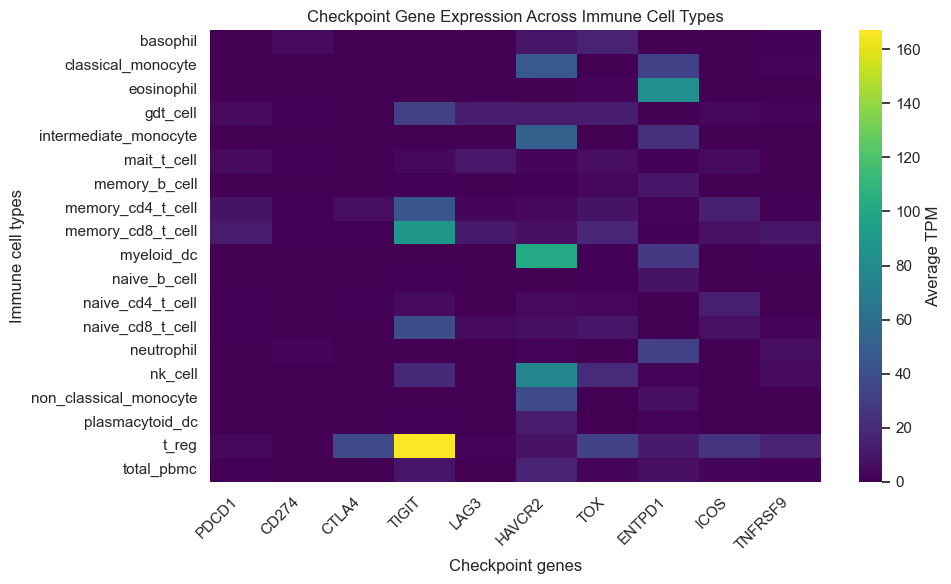

In [4]:
figure_dir = PROJECT_ROOT / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
sns.heatmap(
    wide_expression.set_index("gene").T,
    cmap="viridis",
    cbar_kws={"label": "Average TPM"},
)
plt.title("Checkpoint Gene Expression Across Immune Cell Types")
plt.xlabel("Checkpoint genes")
plt.ylabel("Immune cell types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figure_dir / "checkpoint_expression_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## Top expressing cell types

The ranked table identifies the strongest cell-type signals for each gene.

In [5]:
top_table = ranked_expression.groupby("gene", group_keys=False).head(5)
top_table

,gene,rank,cell_type,expression
0,CD274,1,basophil,5.0
1,CD274,2,neutrophil,2.3
2,CD274,3,memory_cd4_t_cell,1.3
3,CD274,4,mait_t_cell,1.2
4,CD274,5,memory_cd8_t_cell,1.1
19,CTLA4,1,t_reg,36.1
20,CTLA4,2,memory_cd4_t_cell,5.4
21,CTLA4,3,naive_cd4_t_cell,1.2
22,CTLA4,4,memory_cd8_t_cell,0.7
23,CTLA4,5,gdt_cell,0.6


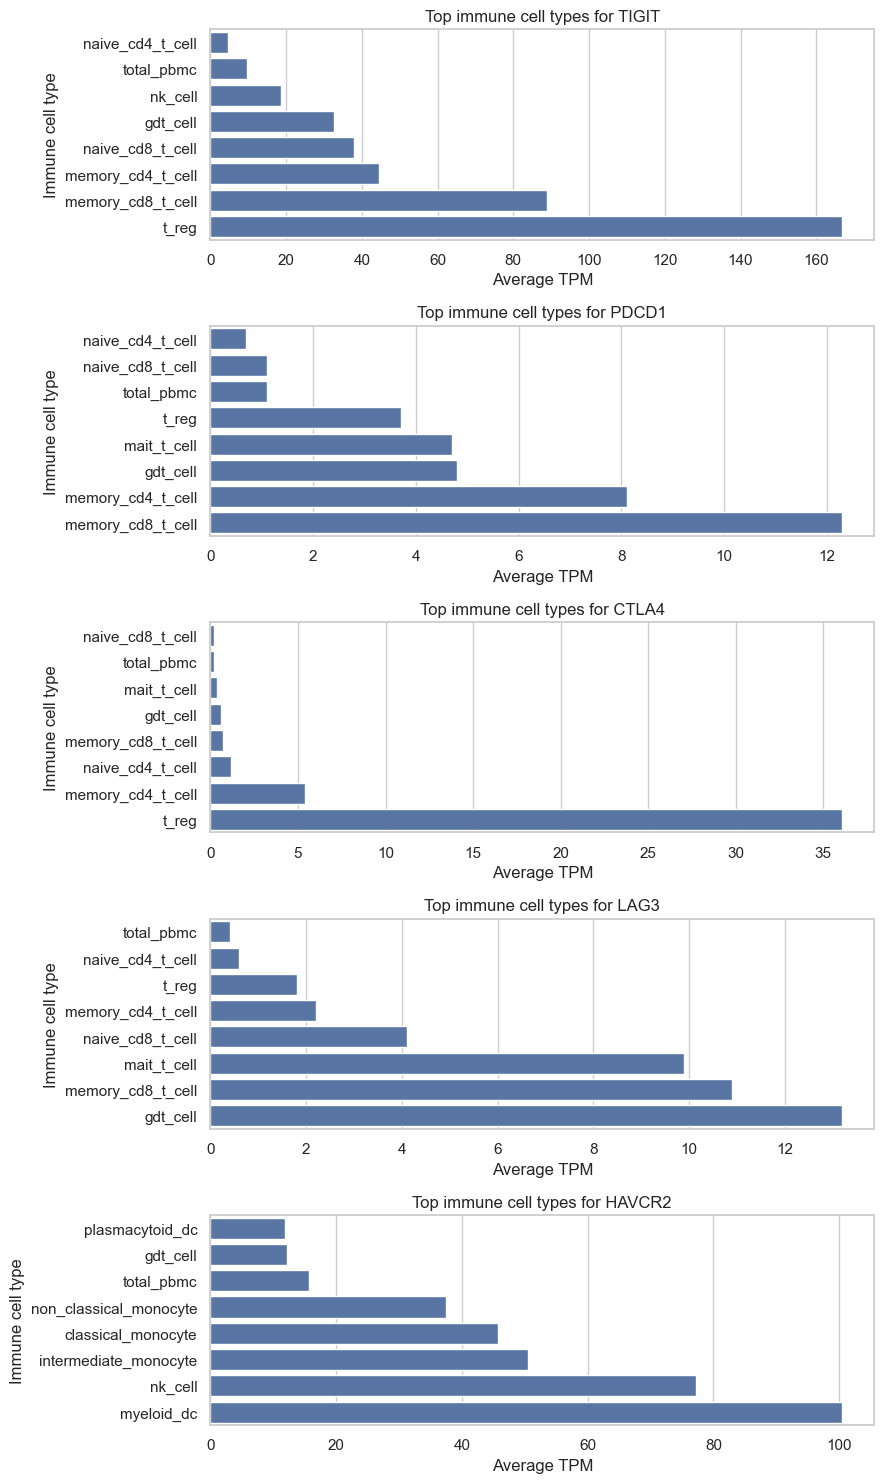

In [6]:
top_gene_plots = ["TIGIT", "PDCD1", "CTLA4", "LAG3", "HAVCR2"]
fig, axes = plt.subplots(len(top_gene_plots), 1, figsize=(9, 15))

for axis, gene in zip(axes, top_gene_plots):
    subset = (
        ranked_expression.loc[ranked_expression["gene"] == gene]
        .nsmallest(8, "rank")
        .sort_values("expression")
    )
    sns.barplot(data=subset, x="expression", y="cell_type", color="#4c72b0", ax=axis)
    axis.set_title(f"Top immune cell types for {gene}")
    axis.set_xlabel("Average TPM")
    axis.set_ylabel("Immune cell type")

plt.tight_layout()
plt.show()

## Gene group profiles

Checkpoint genes are grouped into broad inhibitory, ligand, activation, and functional categories to compare average group-level expression by cell type.

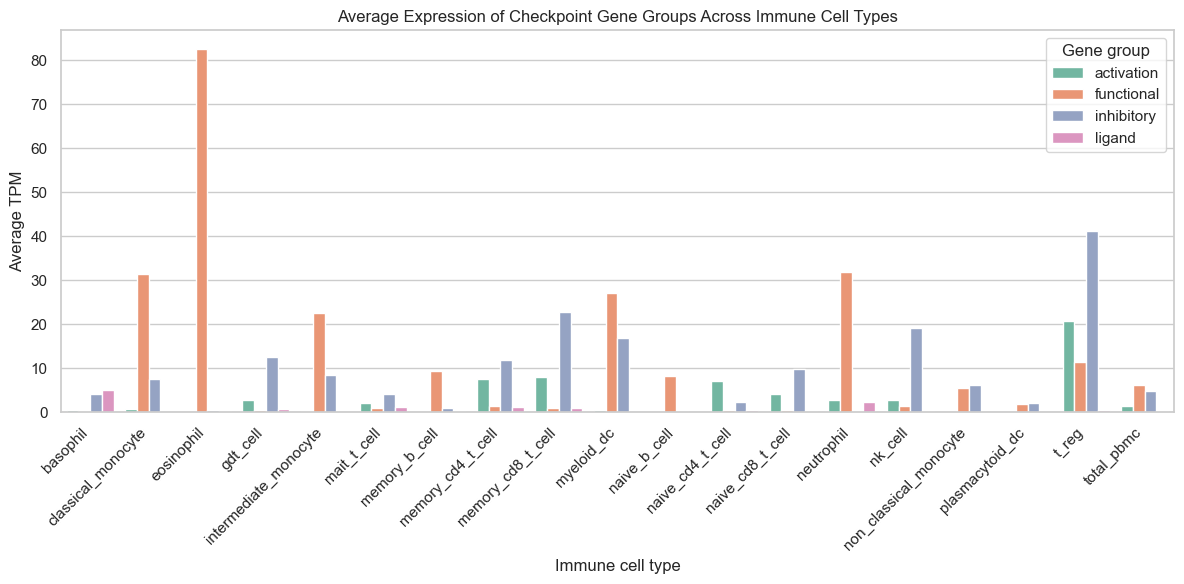

In [7]:
gene_groups = {
    "inhibitory": ["PDCD1", "CTLA4", "TIGIT", "LAG3", "HAVCR2", "TOX"],
    "ligand": ["CD274"],
    "activation": ["ICOS", "TNFRSF9"],
    "functional": ["ENTPD1"],
}

grouped_expression = long_expression.copy()
grouped_expression["group"] = None
for group_name, group_genes in gene_groups.items():
    grouped_expression.loc[grouped_expression["gene"].isin(group_genes), "group"] = group_name

group_summary = (
    grouped_expression.groupby(["cell_type", "group"], as_index=False)["expression"].mean()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=group_summary, x="cell_type", y="expression", hue="group", palette="Set2")
plt.title("Average Expression of Checkpoint Gene Groups Across Immune Cell Types")
plt.xlabel("Immune cell type")
plt.ylabel("Average TPM")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gene group")
plt.tight_layout()
plt.savefig(figure_dir / "checkpoint_gene_groups_by_cell_type.png", dpi=200, bbox_inches="tight")
plt.show()

## Gene-gene relationships

Correlations compare each pair of genes across immune cell types.

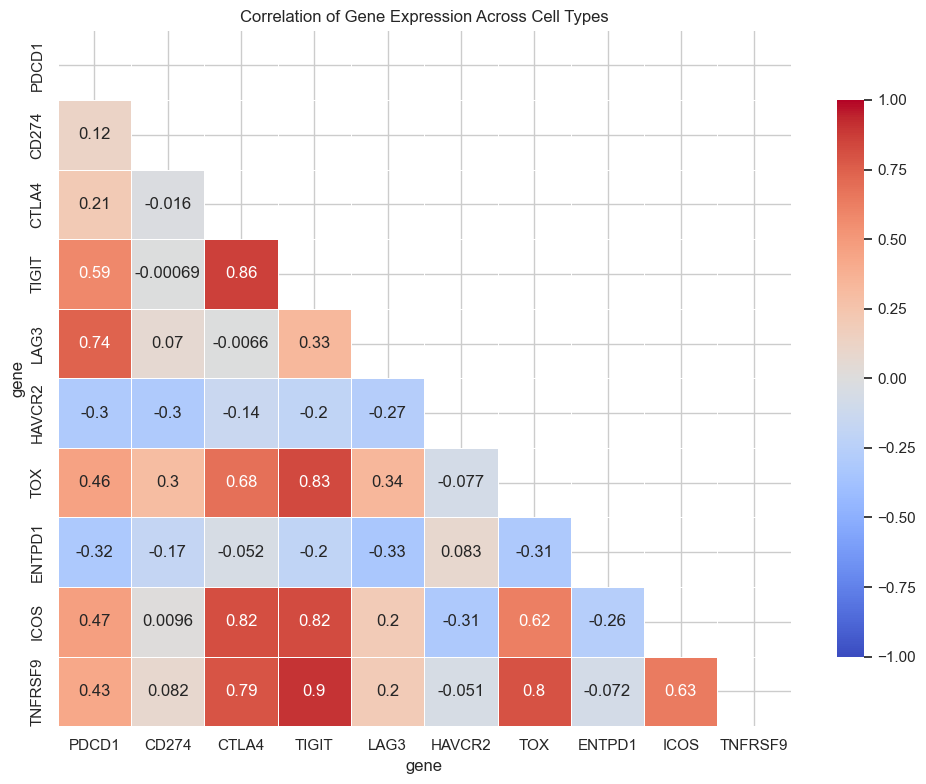

gene,PDCD1,CD274,CTLA4,TIGIT,LAG3,HAVCR2,TOX,ENTPD1,ICOS,TNFRSF9
gene,,,,,,,,,,
PDCD1,1.00,0.12,0.21,0.59,0.74,-0.30,0.46,-0.32,0.47,0.43
CD274,0.12,1.00,-0.02,-0.00,0.07,-0.30,0.30,-0.17,0.01,0.08
CTLA4,0.21,-0.02,1.00,0.86,-0.01,-0.14,0.68,-0.05,0.82,0.79
TIGIT,0.59,-0.00,0.86,1.00,0.33,-0.20,0.83,-0.20,0.82,0.90
LAG3,0.74,0.07,-0.01,0.33,1.00,-0.27,0.34,-0.33,0.20,0.20
HAVCR2,-0.30,-0.30,-0.14,-0.20,-0.27,1.00,-0.08,0.08,-0.31,-0.05
TOX,0.46,0.30,0.68,0.83,0.34,-0.08,1.00,-0.31,0.62,0.80
ENTPD1,-0.32,-0.17,-0.05,-0.20,-0.33,0.08,-0.31,1.00,-0.26,-0.07
ICOS,0.47,0.01,0.82,0.82,0.20,-0.31,0.62,-0.26,1.00,0.63


In [8]:
gene_matrix = wide_expression.set_index("gene")
gene_correlation = gene_matrix.T.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(gene_correlation, dtype=bool))
sns.heatmap(
    gene_correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation of Gene Expression Across Cell Types")
plt.tight_layout()
plt.savefig(figure_dir / "gene_gene_correlations.png", dpi=200, bbox_inches="tight")
plt.show()

gene_correlation.round(2)

## Main findings

- TIGIT has the strongest overall expression signal, led by T reg cells, memory CD8 T cells, and memory CD4 T cells.
- CTLA4 is concentrated in T reg cells, with much lower expression in other immune cell types.
- PDCD1 is highest in memory CD8 T cells, memory CD4 T cells, and GDT cells.
- HAVCR2 is strongest in myeloid DC, NK cells, and intermediate monocytes, giving it a profile distinct from the T-cell-enriched checkpoints.
- ENTPD1 is strongest in eosinophils, neutrophils, and classical monocytes.
- TIGIT, TNFRSF9, CTLA4, ICOS, and TOX show related T-cell-enriched patterns, while CD274 is comparatively modest and strongest in basophils and neutrophils.

These results describe RNA expression only. They do not prove protein abundance, receptor-ligand activity, or functional immune suppression.